# 05 — Loss Calculation

**Purpose:** Translate damage probabilities into economic losses using Hazus
damage ratios, and compute portfolio-level loss metrics.

## Input Files

| File | Format | Description |
|------|--------|-------------|
| `config.yaml` | YAML | Region bounds, IM type |
| `data/grid.xml` | XML (ShakeMap) | Ground motion grid |
| `data/CA24.txt` | Fixed-width text (NBI) | Bridge inventory with structural attributes |
| Built-in: `HAZUS_DAMAGE_RATIOS` | Python dict | Fraction of replacement cost per damage state |
| Built-in: `HAZUS_DOWNTIME_DAYS` | Python dict | Restoration time per damage state |

## Outputs (in-memory)

| Object | Type | Description |
|--------|------|-------------|
| `loss_df` | `pd.DataFrame` (~2953 × 7) | Per-bridge: structure_number, hwb_class, sa, replacement_cost, expected_loss (USD), loss_ratio, expected_downtime (days) |
| `result` | `PortfolioLossResult` | Aggregated: total_loss, loss_ratio, loss_by_class, count_by_ds, total_downtime |

## Expected Plots

- **Loss by HWB class** — horizontal bar chart, x = expected loss (USD), y = HWB class

## Expected Values (Northridge)

- Total replacement value: ~$17.2 billion
- Total expected loss: ~$1.3 billion (loss ratio ~7.6%)
- Dominant class: HWB17 (~55% of total loss)

**Key concepts:** Damage ratios (Hazus Table 7.11), E[L] = Σ P(ds) × DR(ds) × RC,
replacement cost estimation, portfolio aggregation

## Imports & Setup

In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src.config import load_config, IM_COLUMN_MAP
from src.data_loader import load_shakemap, load_nbi, classify_nbi_to_hazus
from src.interpolation import interpolate_im
from src.exposure import BridgeExposure, estimate_replacement_cost
from src.loss import (
    compute_bridge_loss, compute_portfolio_loss, loss_summary_table,
    HAZUS_DAMAGE_RATIOS, HAZUS_DOWNTIME_DAYS,
)

pd.set_option("display.max_columns", 20)
pd.set_option("display.float_format", "{:,.2f}".format)
%matplotlib inline

## Step 1: Hazus Damage Ratios

The damage ratio is the fraction of replacement cost incurred at each damage state.
Source: FEMA Hazus 6.1, Table 7.11.

**Output:** 5-row table: none (0%), slight (3%), moderate (8%), extensive (25%), complete (100%).
Also shows restoration downtime: none (0 days), slight (0.6), moderate (2.5), extensive (75), complete (230).

In [2]:
ratio_df = pd.DataFrame({
    "Damage State": HAZUS_DAMAGE_RATIOS.keys(),
    "Damage Ratio": HAZUS_DAMAGE_RATIOS.values(),
    "Downtime (days)": HAZUS_DOWNTIME_DAYS.values(),
})
display(ratio_df)

,Damage State,Damage Ratio,Downtime (days)
0,none,0.00,0.00
1,slight,0.03,0.60
2,moderate,0.08,2.50
3,extensive,0.25,75.00
4,complete,1.00,230.00


## Step 2: Load Bridges with IM Values

In [3]:
cfg = load_config(PROJECT_ROOT / "config.yaml")
grid = load_shakemap(PROJECT_ROOT / "data" / "grid.xml")
nbi = load_nbi(PROJECT_ROOT / "data" / "CA24.txt", northridge_bbox=cfg.region)
nbi = classify_nbi_to_hazus(nbi)

im_col = IM_COLUMN_MAP.get(cfg.im_type, "PSA10")
nbi["sa"] = interpolate_im(
    grid["LAT"].values, grid["LON"].values, grid[im_col].values,
    nbi["latitude"].values, nbi["longitude"].values,
    method="nearest",
)

# Estimate replacement costs
nbi["replacement_cost"] = nbi.apply(
    lambda r: estimate_replacement_cost(
        r.get("material", "concrete"),
        r.get("deck_width_m", 10.0) * r.get("structure_length_m", 30.0),
        r.get("structure_length_m", 30.0),
    ),
    axis=1,
)

print(f"Bridges: {len(nbi)}")
print(f"Total replacement value: ${nbi['replacement_cost'].sum():,.0f}")

Bridges: 2953
Total replacement value: $17,216,910,160


## Step 3: Per-Bridge Expected Loss

In [4]:
loss_results = []
for _, row in nbi.iterrows():
    result = compute_bridge_loss(
        sa=row["sa"],
        hwb_class=row["hwb_class"],
        replacement_cost=row["replacement_cost"],
        bridge_id=row["structure_number"],
    )
    loss_results.append({
        "structure_number": result.bridge_id,
        "hwb_class": row["hwb_class"],
        "sa": result.sa,
        "replacement_cost": result.replacement_cost,
        "expected_loss": result.expected_loss,
        "loss_ratio": result.loss_ratio,
        "expected_downtime": result.expected_downtime,
    })

loss_df = pd.DataFrame(loss_results)
print(f"Total expected loss: ${loss_df['expected_loss'].sum():,.0f}")
print(f"Portfolio loss ratio: {loss_df['expected_loss'].sum() / loss_df['replacement_cost'].sum():.4f}")

Total expected loss: $1,309,050,449
Portfolio loss ratio: 0.0760


## Step 4: Top 10 Highest-Loss Bridges

**Expected display:** 10-row table sorted by expected_loss descending. Shows structure_number,
hwb_class, sa (g), replacement_cost (USD), expected_loss (USD), loss_ratio, expected_downtime (days).

In [5]:
display(
    loss_df.nlargest(10, "expected_loss")
    [["structure_number", "hwb_class", "sa", "replacement_cost",
      "expected_loss", "loss_ratio", "expected_downtime"]]
    .reset_index(drop=True)
)

,structure_number,hwb_class,sa,replacement_cost,expected_loss,loss_ratio,expected_downtime
0,53 1301,HWB1,0.21,"2,815,318,076.17","50,102,818.04",0.02,3.09
1,53 2216G,HWB2,1.11,"107,929,700.06","34,734,239.40",0.32,75.29
2,53 2974E,HWB2,1.17,"54,683,100.00","19,272,836.77",0.35,82.58
3,53 2182,HWB1,0.84,"32,882,996.66","16,991,883.20",0.52,118.25
4,53 0730,HWB17,1.20,"19,553,392.74","16,637,695.09",0.85,197.45
5,53 1984R,HWB1,1.17,"20,759,225.22","14,830,112.13",0.71,164.54
6,53 2027,HWB1,0.68,"36,816,681.76","14,174,168.02",0.38,87.23
7,53 1984L,HWB1,1.26,"18,262,606.83","13,752,826.71",0.75,173.54
8,53 2925,HWB2,1.01,"40,327,573.19","11,088,437.00",0.27,64.08
9,53 1962F,HWB1,1.17,"14,590,772.88","10,423,452.49",0.71,164.54


## Step 5: Portfolio Loss via compute_portfolio_loss

Build `BridgeExposure` objects and use the portfolio-level function
for aggregated metrics.

In [6]:
# Build exposure portfolio
portfolio = []
for _, row in nbi.iterrows():
    portfolio.append(BridgeExposure(
        bridge_id=row["structure_number"],
        lat=row["latitude"],
        lon=row["longitude"],
        hwb_class=row["hwb_class"],
        material=row.get("material", "concrete"),
        length=row.get("structure_length_m", 30.0),
        deck_area=row.get("deck_width_m", 10.0) * row.get("structure_length_m", 30.0),
        replacement_cost=row["replacement_cost"],
    ))

result = compute_portfolio_loss(portfolio, nbi["sa"].values)
print(loss_summary_table(result))

PORTFOLIO LOSS SUMMARY
  Bridges analyzed:        2,953
  Total replacement cost:  $17,216,910,160
  Expected total loss:     $1,309,050,449
  Portfolio loss ratio:    0.0760 (7.60%)
  Total downtime:          64,293 bridge-days

-----------------------------------------------------------------
EXPECTED DAMAGE STATE DISTRIBUTION
-----------------------------------------------------------------
          None: 2142.1 bridges ( 72.5%)
        Slight:  247.6 bridges (  8.4%)
      Moderate:  153.5 bridges (  5.2%)
     Extensive:  196.7 bridges (  6.7%)
      Complete:  213.1 bridges (  7.2%)

-----------------------------------------------------------------
LOSS BY BRIDGE CLASS
-----------------------------------------------------------------
  HWB17     $   715,154,852  ( 54.6%)
  HWB1      $   243,145,303  ( 18.6%)
  HWB2      $   177,735,569  ( 13.6%)
  HWB3      $    46,899,521  (  3.6%)
  HWB5      $    38,475,604  (  2.9%)
  HWB4      $    32,863,877  (  2.5%)
  HWB8      $    15,7

## Step 6: Loss by HWB Class

**Expected plot:** Horizontal bar chart (10×6 inch). Y-axis = HWB class labels, X-axis = expected loss in USD
(formatted as $X,XXX). HWB17 dominates (~$715M) followed by HWB1 (~$243M) and HWB2 (~$178M).

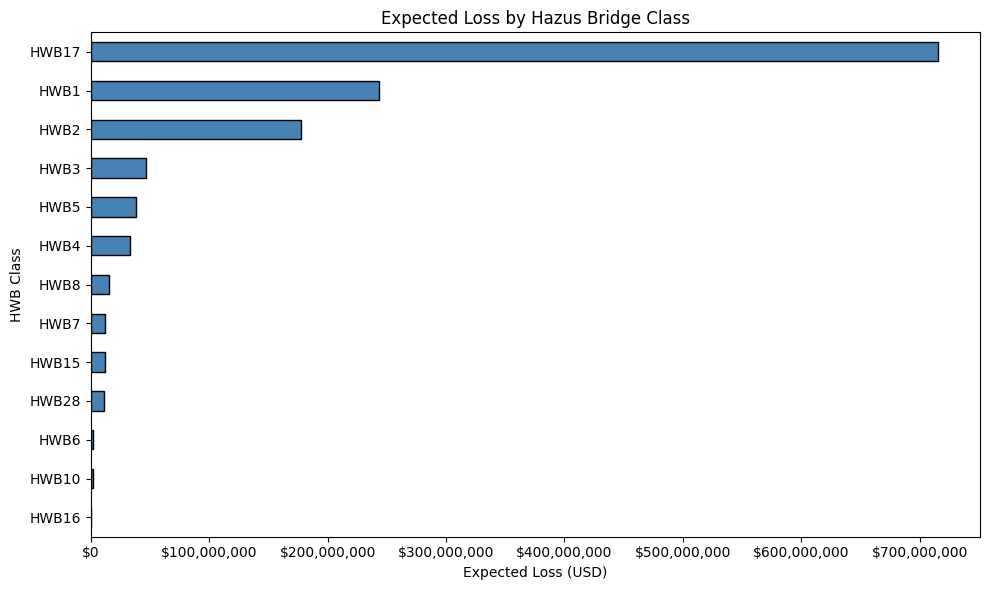

In [7]:
class_loss = loss_df.groupby("hwb_class")["expected_loss"].sum().sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(10, 6))
class_loss.plot.barh(ax=ax, color="steelblue", edgecolor="k")
ax.set_xlabel("Expected Loss (USD)")
ax.set_ylabel("HWB Class")
ax.set_title("Expected Loss by Hazus Bridge Class")
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"${x:,.0f}"))
plt.tight_layout()
plt.show()

## Summary

In this notebook we:
1. Reviewed Hazus damage ratios and downtime estimates
2. Computed per-bridge expected loss and downtime
3. Identified the top 10 highest-loss bridges
4. Computed portfolio-level loss metrics
5. Visualized loss distribution by HWB class

**Next:** [06_validation.ipynb](06_validation.ipynb) — Validation against observations